In [59]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../blood_data.duckdb")


In [5]:
df = con.execute("select * from historical").df()

df.head()

,inst_code,visit_date,previous_visit,donation_type,donation_location,classification_id,blood_group
0,11-14010001,2006-01-01,1800-08-10,1,M,C,B
1,11-02030085,2006-01-01,2005-12-18,1,U,C,B
2,11-02030085,2006-01-01,2005-06-30,1,U,C,A
3,11-14010001,2006-01-01,1800-08-10,1,M,C,O
4,11-14010001,2006-01-01,1800-08-10,1,M,C,O


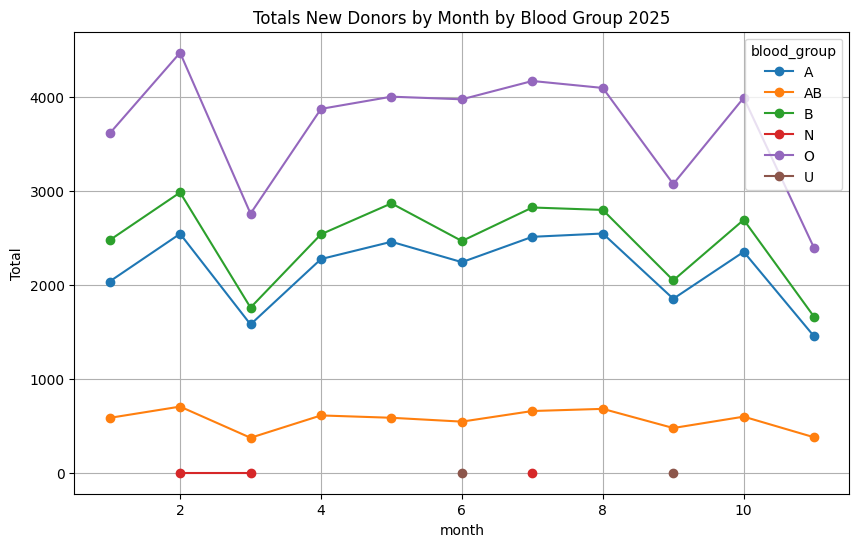

In [41]:
query = "select MONTH(visit_date) as month,blood_group,count(blood_group) as total from historical where YEAR(visit_date) = 2025 and YEAR(previous_visit) = 1800 group by MONTH(visit_date),blood_group order by month,blood_group"

result = con.sql(query).df()

pivot_df = result.pivot(index='month', columns='blood_group', values='total')


pivot_df.plot(marker='o', figsize=(10, 6))

plt.title("Totals New Donors by Month by Blood Group 2025")
plt.ylabel("Total")
plt.grid(True)
plt.show()

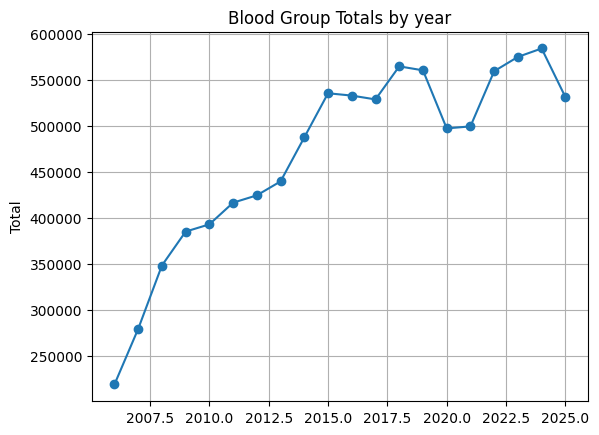

In [ ]:
query = "select YEAR(visit_date) as year,count(*) as total from historical group by year order by year"

result = con.sql(query).df()
result
plt.plot(result['year'],result['total'] ,marker='o')

plt.title("Totals Blood Donation by Year")
plt.ylabel("Total")
plt.grid(True)
plt.show()

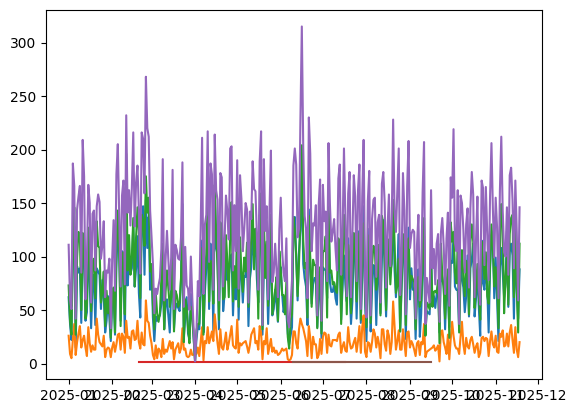

In [31]:
query = """select visit_date as day,blood_group,count(blood_group) as total from historical 
        where 1 
        and YEAR(visit_date) = 2025 
        and YEAR(previous_visit) = 1800 
        group by day,blood_group order by day,blood_group"""

result = con.sql(query).df()

query1 = "select distinct blood_group from historical order by blood_group "
blood_groups = con.execute(query1).df()
df
for bg in blood_groups['blood_group']:
    data = result[result['blood_group'] == bg]
    plt.plot(data['day'],data['total'])

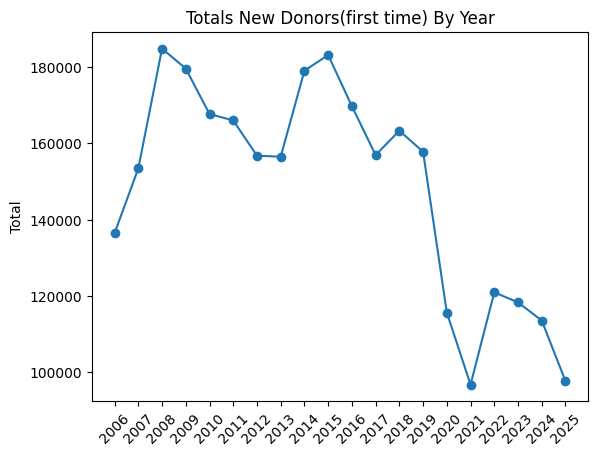

In [57]:
query = "select year(visit_date) as year,count(blood_group) as total from historical where YEAR(previous_visit) = 1800 group by year, order by year"

result = con.sql(query).df()

result


plt.plot(result['year'], result['total'], marker='o')
plt.xticks(result['year'], rotation=45)

plt.title("Totals New Donors(first time) By Year")
plt.ylabel("Total")
# plt.grid(True)
plt.show()

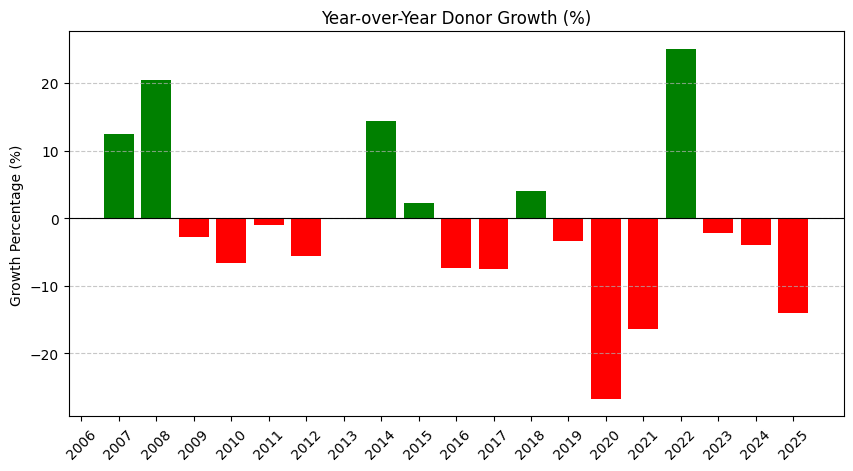

In [62]:
query = "select year(visit_date) as year,count(blood_group) as total from historical where YEAR(previous_visit) = 1800 group by year, order by year"

result = con.sql(query).df()

# result

# 1. Calculate the percentage change
# pct_change() calculates the change from the previous row
result['growth_pct'] = result['total'].pct_change() * 100
result
# 2. Create color logic (Green for up, Red for down)
colors = ['green' if x >= 0 else 'red' for x in result['growth_pct']]

# 3. Plot
plt.figure(figsize=(10, 5))
plt.bar(result['year'], result['growth_pct'], color=colors)

# Formatting
plt.axhline(0, color='black', linewidth=0.8) # Adds a zero line
plt.title("Year-over-Year Donor Growth (%)")
plt.ylabel("Growth Percentage (%)")
plt.xticks(result['year'], rotation=45) # Shows all years
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

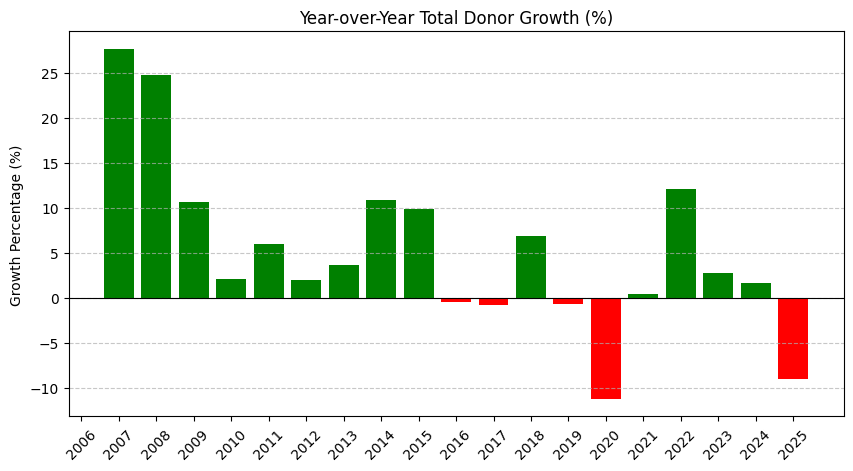

In [ ]:
query = "select YEAR(visit_date) as year,count(*) as total from historical group by year order by year"

result = con.sql(query).df()
# result

result['growth_pct'] = result['total'].pct_change() * 100
result

colors = ['green' if x >= 0 else 'red' for x in result['growth_pct']]


plt.figure(figsize=(10, 5))
plt.bar(result['year'], result['growth_pct'], color=colors)


plt.axhline(0, color='black', linewidth=0.8) # Adds a zero line
plt.title("Year-over-Year Total Donor Growth (%)")
plt.ylabel("Growth Percentage (%)")
plt.xticks(result['year'], rotation=45) # Shows all years
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

<BarContainer object of 999 artists>

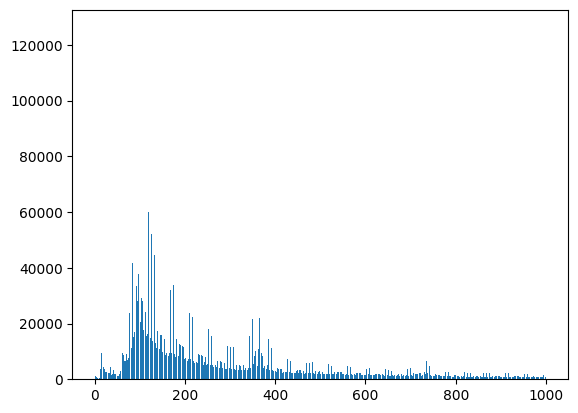

In [96]:
query = """

    select (visit_date - previous_visit) as diff_days , count((visit_date - previous_visit)) as total from historical
    where YEAR(previous_visit) <> 1800
    and  (visit_date - previous_visit) < 1000
    group by diff_days
    order by diff_days
"""

result = con.sql(query).df()
result

plt.bar(result['diff_days'],result['total'])

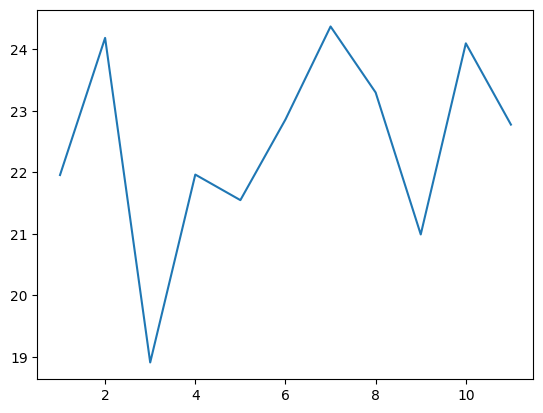

In [17]:
varible = "month"

#Total  Donation
query = f"""

    select {varible}(visit_date) as {varible} , 
    sum (case when YEAR(previous_visit) <> 1800 THEN 1 else 0 END) as total_returning_donor,
    sum(case when YEAR(previous_visit) = 1800 THEN 1 else 0 END) as total_new_donor,
    count(*) as total_donation,
    ((total_new_donor/total_returning_donor) * 100) as ratio_new_returning
    from historical
    where 1
    and YEAR(visit_date) = 2025
    group by {varible}
    order by {varible}
"""

"""
and YEAR(visit_date) = 2025
"""

result = con.sql(query).df()
# result

plt.plot(result[f'{varible}'],result['ratio_new_returning'])
plt.show()

In [ ]:
varible = "year"


query = f"""

    select {varible}(visit_date) as {varible} , 
    (case when YEAR(previous_visit) <> 1800 THEN 1 else 0 END) as total_returning_donor,
    (case when YEAR(previous_visit) = 1800 THEN 1 else 0 END) as total_new_donor,
    count(*) as total_donation,
    ((total_new_donor/total_returning_donor) * 100) as ratio_new_returning
    from historical
    where 1
    group by {varible}
    order by {varible}
"""

# and YEAR(visit_date) = 2025


result = con.sql(query).df()
result

# plt.plot(result[f'{varible}'],result['ratio_new_returning'])
# plt.show()

,year,total_returning_donor,total_new_donor,total_donation,ratio_new_returning
0,2006,82466.0,136426.0,218892,165.433027
1,2007,125948.0,153430.0,279378,121.820116
2,2008,163517.0,184850.0,348367,113.046350
3,2009,205646.0,179634.0,385280,87.351079
4,2010,225451.0,167712.0,393163,74.389557
5,2011,250738.0,166013.0,416751,66.209749
6,2012,267946.0,156780.0,424726,58.511790
7,2013,283415.0,156492.0,439907,55.216555
8,2014,308734.0,179072.0,487806,58.002034
9,2015,352651.0,183171.0,535822,51.941154


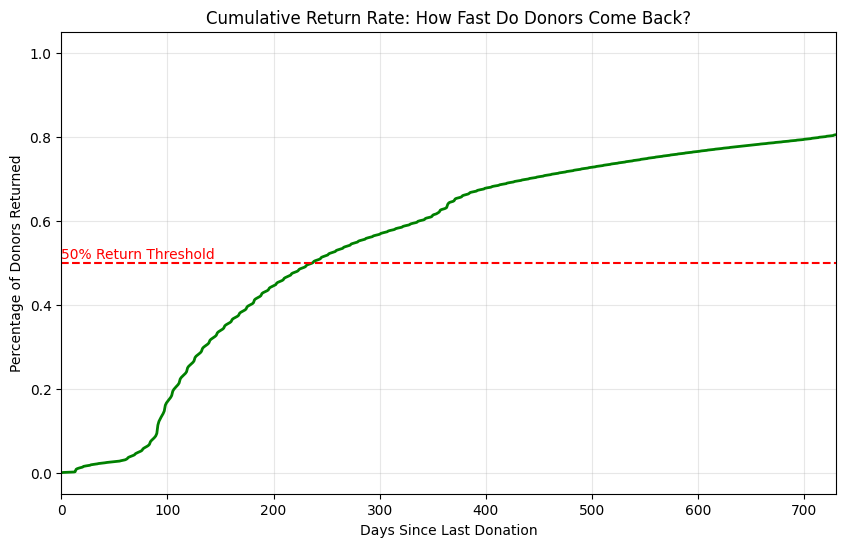

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Get Data (Using your previous logic)
# We get the 'diff_days'. Since these are historical records, 
# the "Event" (return) actually happened for all of them.
query = """
    SELECT 
        (visit_date - previous_visit) as diff_days,
        1 as event_occurred  
    FROM historical
    WHERE YEAR(previous_visit) <> 1800
    order by diff_days
"""
df = con.sql(query).df()

# df

kmf = KaplanMeierFitter()
kmf.fit(durations=df['diff_days'], event_observed=df['event_occurred'])

# PLOT STRATEGY: Use (1 - survival_function)
plt.figure(figsize=(10, 6))

# This flips the graph: Starts at 0, goes up to 1
plt.plot(kmf.cumulative_density_, color="green", linewidth=2)

plt.title('Cumulative Return Rate: How Fast Do Donors Come Back?')
plt.xlabel('Days Since Last Donation')
plt.ylabel('Percentage of Donors Returned')
plt.grid(True, alpha=0.3)
plt.xlim(0, 730) 

# Add a reference line for 50% return rate
plt.axhline(y=0.5, color='red', linestyle='--')
plt.text(0, 0.51, '50% Return Threshold', color='red')

plt.show()

In [27]:
import requests

# Your link (cleaned of the ');' at the end)
url = "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/MYS/ADM1/geoBoundaries-MYS-ADM1_simplified.geojson"

response = requests.get(url)
data = response.json()

# Let's look at the properties of the first state to find the right key
first_state = data['features'][0]['properties']
print("Available Keys:", first_state.keys())
print("Example Name:", first_state['shapeName'])

Available Keys: dict_keys(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType'])
Example Name: Selangor


In [63]:
query = "select ST_AsText(geom) from malaysia_states;"

df= con.sql(query).df()
df

,st_astext(geom)
0,"MULTIPOLYGON (((101.2499 2.907715554176605, 10..."
1,"MULTIPOLYGON (((104.0624 2.217938532369939, 10..."
2,"POLYGON ((101.628069 3.138012, 101.6296007 3.1..."
3,"MULTIPOLYGON (((102.3192095 2.1114455, 102.324..."
4,"POLYGON ((101.7124503 2.5953285, 101.7187991 2..."
5,MULTIPOLYGON (((117.62919269999998 4.201556700...
6,"MULTIPOLYGON (((110.2974526 1.6634805, 110.301..."
7,"POLYGON ((101.69131 5.755099, 101.6905189 5.74..."
8,"POLYGON ((101.6804586 2.8805165, 101.6806176 2..."
9,"MULTIPOLYGON (((103.67313349999995 4.8032733, ..."


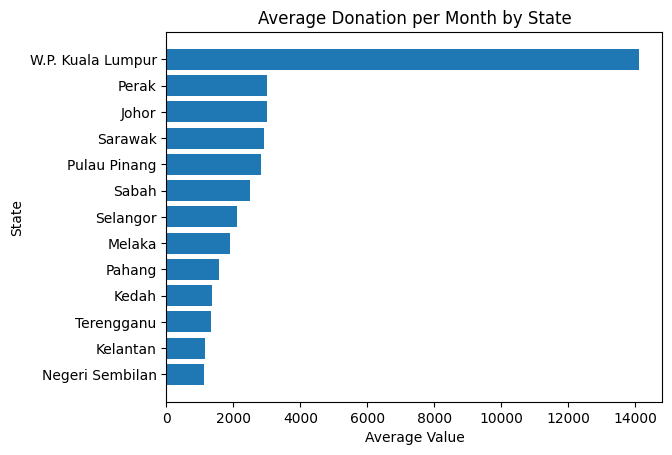

In [106]:

query = """
            select ic.state, MONTH(h.visit_date) as mon , count(*) as total
            from historical h left join inst_code ic
            on h.inst_code = ic.inst_code
            where 1
            and YEAR(previous_visit) <> 1800
            and YEAR(visit_date) = 2025
            group by ic.state , mon
            order by ic.state,  mon

        """

dff= con.sql(query).df()

query1 = """
            select d.state , AVG(d.total) as average 
            from dff d 
            where state is not null
            group by state
            order by average 
            
         """
df = con.sql(query1).df()

df

plt.barh(df['state'],df['average'])
plt.title('Average Donation per Month by State')
plt.xlabel('Average Value')
plt.ylabel('State')

plt.show()

In [107]:
query = """
            select ic.state, MONTH(h.visit_date) as mon , count(*) as total
            from historical h left join inst_code ic
            on h.inst_code = ic.inst_code
            where 1
            and YEAR(previous_visit) <> 1800
            and YEAR(visit_date) = 2025
            and state LIKE '%Lumpur%'
            group by ic.state , mon
            order by ic.state,  mon

        """

df= con.sql(query).df()
df

,state,mon,total
0,W.P. Kuala Lumpur,1,14601
1,W.P. Kuala Lumpur,2,16488
2,W.P. Kuala Lumpur,3,10920
3,W.P. Kuala Lumpur,4,15088
4,W.P. Kuala Lumpur,5,16366
5,W.P. Kuala Lumpur,6,14940
6,W.P. Kuala Lumpur,7,14629
7,W.P. Kuala Lumpur,8,15181
8,W.P. Kuala Lumpur,9,13348
9,W.P. Kuala Lumpur,10,13510


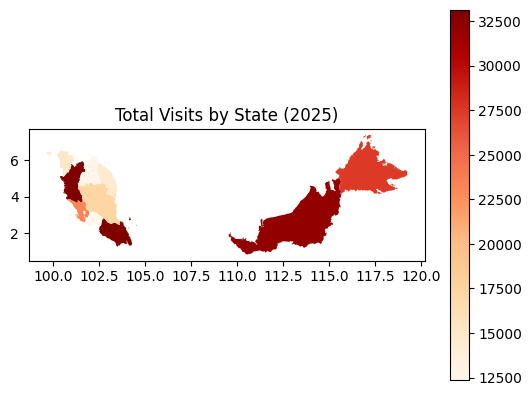

In [70]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

# 2. Convert the text (WKT) to geometry
#    We apply the wkt.loads function to every row
df['geometry'] = df['geom_text'].apply(wkt.loads)

# 3. Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# 4. Plot
fig, ax = plt.subplots(1, 1)
gdf.plot(column='total', legend=True, ax=ax, cmap='OrRd')

plt.title("Total Visits by State (2025)")
plt.show()

In [55]:
con.close()